# **Projet 4 - Analyse des causes d'attrition au sein d'une ESN**

> - Réaliser une analyse exploratoire des données afin d'identifier les principales tendances et différences entre les employés.
> - Identifier les facteurs potentiellement associés à l'attrition des employés.
> - Préparer et nettoyer les données afin de construire un jeu de données centralisé et exploitable pour la modélisation.
> - Comparer plusieurs modèles de classification supervisée afin de prédire le risque d'attrition.
> - Identifier les variables ayant le plus d'influence sur l'attrition des employés.

## **Contexte**

> -  Une entreprise de services du numérique (ESN) souhaite mieux comprendre les facteurs associés au départ de ses employés.
> - L'entreprise dispose de plusieurs fichiers de données contenant des informations sur les employés, leur situation professionnelle et leurs caractéristiques.
> - L'objectif est d'explorer et de croiser ces données afin d'identifier les principales tendances associées à l'attrition et de préparer les données pour la modélisation prédictive.

 ## **Objectif**
> - Identifier les principaux facteurs associés à l'attrition des employés afin de mieux comprendre les causes de départ au sein de l'ESN et de construire un modèle permettant de prédire le risque d'attrition.

## **Objectifs Data**

> - **E5 - Optimiser et interpréter le modèle :** optimiser les hyperparamètres du modèle retenu, évaluer ses performances et identifier les variables ayant le plus d'influence sur l'attrition à l'aide de SHAP.

## **ÉTAPE 5 - Optimiser et interpréter le modèle**

### **Importation des librairies**

In [23]:
# Installation de shap

import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "shap"
])

print("shap installed successfully.")

shap installed successfully.


In [24]:
# Importation des librairies

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Fine-tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Feature importance
from sklearn.inspection import permutation_importance

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Interprétabilité
import shap

print("Importation des librairies OK")

Importation des librairies OK


In [25]:
# importation des modules

# Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

# Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Fine-tuning
from scipy.stats import randint

# Feature importance
from sklearn.inspection import permutation_importance

# Interprétabilité
import shap

from sklearn.metrics import make_scorer

print("Importation des modules OK")

Importation des modules OK


### **Chargement des jeux des données**

In [26]:
# Importation du fichier central

df_modelisation = pd.read_csv("../data/processed/df_modelisation.csv", index_col=0)

print("Importation du fichier central OK")
print(f"Dimensions du dataset : {df_modelisation.shape[0]} lignes, {df_modelisation.shape[1]} colonnes")

display(df_modelisation.head())

Importation du fichier central OK
Dimensions du dataset : 1470 lignes, 46 colonnes


,nominal__genre_M,nominal__statut_marital_Célibataire,nominal__statut_marital_Divorcé(e),nominal__statut_marital_Marié(e),nominal__departement_Commercial,nominal__departement_Consulting,nominal__departement_Ressources Humaines,nominal__poste_Assistant de Direction,nominal__poste_Cadre Commercial,nominal__poste_Consultant,...,remainder__satisfaction_employee_equipe,remainder__satisfaction_employee_equilibre_pro_perso,remainder__note_evaluation_actuelle,remainder__augementation_salaire_precedente,remainder__nombre_participation_pee,remainder__nb_formations_suivies,remainder__distance_domicile_travail,remainder__niveau_education,remainder__annees_depuis_la_derniere_promotion,a_quitte_l_entreprise
nominal__genre_F,,,,,,,,,,,,,,,,,,,,,
1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,3.0,11.0,0.0,0.0,1.0,2.0,0.0,Oui
0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,4.0,3.0,4.0,23.0,1.0,3.0,8.0,1.0,1.0,Non
0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,2.0,3.0,3.0,15.0,0.0,3.0,2.0,2.0,0.0,Oui
1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,3.0,3.0,11.0,0.0,3.0,3.0,4.0,3.0,Non
0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,4.0,3.0,3.0,12.0,1.0,3.0,2.0,1.0,2.0,Non


### **Fine-tuning du modèle**

#### **Objecfit**

> - Le modèle retenu à l'étape 4 est un **Random Forest avec pondération des classes**.
> - Une recherche d'**hyperparamètres** est réalisée afin d'identifier une configuration optimisée du modèle.
> - La recherche utilise une **validation croisée stratifiée** sur les données d'entraînement.
> - Le **jeu de test est conservé** pour l'évaluation finale du modèle optimisé.
> - L'objectif est d'améliorer l'équilibre entre **Precision, Recall et F1-score** pour la classe `Oui`.

#### **Recherche d'hyperparamètres**

In [27]:
# Espace de recherche des hyperparamètres

param_distributions = {
    "n_estimators": randint(200, 800),
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"]
}

print("Espace de recherche défini")

Espace de recherche défini


In [28]:
# Score utilisé pour le fine-tuning
f1_oui = make_scorer(
    f1_score,
    pos_label="Oui"
)

# Validation croisée stratifiée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modèle de base
rf_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Recherche aléatoire des hyperparamètres
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=50,
    scoring=f1_oui,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Recherche d'hyperparamètres configurée")

Recherche d'hyperparamètres configurée


### **Séparation stratifiée des données**

> - Les données sont séparées en jeux d'apprentissage et de test avec une **stratification de la variable cible** afin de conserver la proportion des classes.

In [29]:
# Séparation de la variable cible et des features

X = df_modelisation.drop(columns="a_quitte_l_entreprise")
y = df_modelisation["a_quitte_l_entreprise"]

# Séparation stratifiée des jeux d'apprentissage et de test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1176, 45)
X_test  : (294, 45)
y_train : (1176,)
y_test  : (294,)


In [30]:
# Lancement de la recherche d'hyperparamètres

random_search.fit(X_train, y_train)

print("Recherche terminée")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Recherche terminée


#### **Résultats du fine-tuning**

In [31]:
# Affichage des meilleurs résultats du fine-tuning

print("Meilleurs hyperparamètres :")
print(random_search.best_params_)

print("\nMeilleur F1-score moyen (classe Oui) :")
print(round(random_search.best_score_, 4))

Meilleurs hyperparamètres :
{'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 3, 'n_estimators': 756}

Meilleur F1-score moyen (classe Oui) :
0.5436


> - Le **RandomizedSearchCV** a testé 50 combinaisons d'hyperparamètres avec une validation croisée en 5 folds, soit **250 entraînements**.
> - La meilleure configuration obtenue pour le **Random Forest** présente un **F1-score moyen de 0,5436** pour la classe **Oui**.
> - Les meilleurs hyperparamètres sont : `n_estimators=756`, `max_depth=15`, `max_features='sqrt'`, `min_samples_leaf=7`, `min_samples_split=3` et `class_weight='balanced'`.
> - Cette configuration est retenue pour construire le **modèle optimisé**.
> - Le modèle optimisé sera ensuite **évalué sur le jeu de test** avant l'analyse de l'importance des variables.

### **Évaluation du modèle optimisé**

> - Le modèle optimisé est construit à partir des meilleurs hyperparamètres identifiés lors du fine-tuning.
> - Son évaluation est réalisée sur le **jeu de test**, qui n'a pas été utilisé lors de la recherche d'hyperparamètres.
> - Les performances sont évaluées à l'aide de l'**Accuracy, Precision, Recall et F1-score** pour la classe **Oui**, ainsi que du **ROC-AUC**.
> - L'objectif est de vérifier si les performances obtenues lors du fine-tuning se maintiennent sur des données non utilisées pendant l'apprentissage.

#### **Récupération du meilleur modèle**

In [32]:
# Récupération du meilleur modèle
rf_optimise = random_search.best_estimator_

print("Modèle optimisé :", rf_optimise)

Modèle optimisé : RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=7, min_samples_split=3,
                       n_estimators=756, n_jobs=-1, random_state=42)


#### **Prédictions sur le jeu de test**

In [33]:
# Prédictions sur le jeu de test

y_pred_optimise = rf_optimise.predict(X_test)

print("Prédictions réalisées")

Prédictions réalisées


#### **Évaluation**

In [34]:
# Évaluation du modèle optimisé

probabilite_optimise = rf_optimise.predict_proba(X_test)[:, list(rf_optimise.classes_).index("Oui")]

print("Accuracy :", round(accuracy_score(y_test, y_pred_optimise), 3))
print("Precision Oui :", round(precision_score(y_test, y_pred_optimise, pos_label="Oui"), 3))
print("Recall Oui :", round(recall_score(y_test, y_pred_optimise, pos_label="Oui"), 3))
print("F1-score Oui :", round(f1_score(y_test, y_pred_optimise, pos_label="Oui"), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, probabilite_optimise), 3))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_optimise))

Accuracy : 0.82
Precision Oui : 0.455
Recall Oui : 0.638
F1-score Oui : 0.531
ROC-AUC : 0.799

Rapport de classification :
              precision    recall  f1-score   support

         Non       0.93      0.85      0.89       247
         Oui       0.45      0.64      0.53        47

    accuracy                           0.82       294
   macro avg       0.69      0.75      0.71       294
weighted avg       0.85      0.82      0.83       294



> - Le modèle optimisé obtient une **Accuracy de 82,0 %** et un **ROC-AUC de 79,9 %** sur le jeu de test.
> - Pour la classe **Oui**, le modèle atteint une **Precision de 45,5 %**, un **Recall de 63,8 %** et un **F1-score de 53,1 %**.
> - Par rapport au modèle Random Forest initial, le modèle optimisé améliore notamment le **Recall** et le **F1-score** de la classe Oui.
> - Le modèle optimisé est donc retenu pour la suite de l'analyse et sera utilisé pour étudier **l'importance globale et locale des variables**.

### **Feature importance globale**

#### **Permutation Importance Globale**

In [35]:
# Calcul de la Permutation Importance

# F1-score spécifique à la classe Oui
f1_oui = make_scorer(f1_score, pos_label="Oui")

permutation = permutation_importance(
    rf_optimise,
    X_test,
    y_test,
    scoring=f1_oui,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation Importance calculée")

Permutation Importance calculée


#### **Classement des variables**

In [36]:
# Classement des variables selon la Permutation Importance

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(15))

,Feature,Importance
17,nominal__heure_supplementaires_Oui,0.089458
16,nominal__heure_supplementaires_Non,0.071150
32,remainder__satisfaction_employee_environnement,0.056602
29,remainder__nombre_experiences_precedentes,0.027515
33,remainder__note_evaluation_precedente,0.022629
35,remainder__satisfaction_employee_nature_travail,0.020412
4,nominal__departement_Commercial,0.020385
31,remainder__annees_dans_l_entreprise,0.020108
36,remainder__satisfaction_employee_equipe,0.019219
5,nominal__departement_Consulting,0.014979


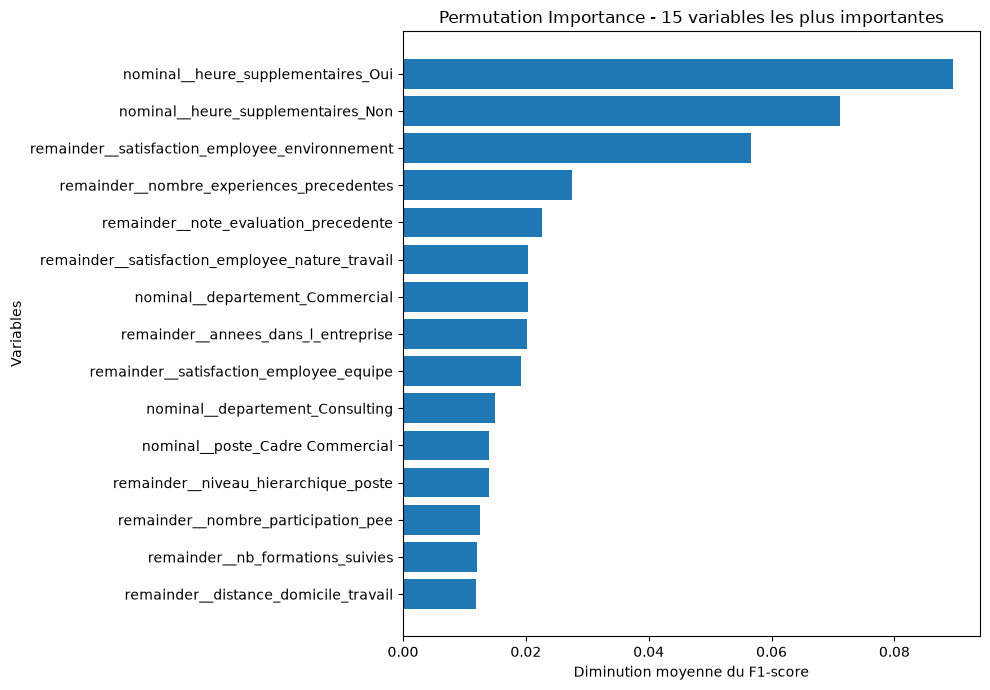

In [37]:
# Visualisation de la Permutation Importance

top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Diminution moyenne du F1-score")
plt.ylabel("Variables")
plt.title("Permutation Importance - 15 variables les plus importantes")

plt.tight_layout()
plt.show()

> - Les variables liées aux **heures supplémentaires** présentent les plus fortes importances selon cette méthode.
> - La **satisfaction de l'environnement de travail** apparaît également comme une variable importante pour les prédictions.
> - D'autres variables liées à l'expérience, à l'évaluation et à la satisfaction des employés présentent une importance plus modérée.
> - Cette analyse permet d'obtenir une première vision globale de l'impact des variables sur les performances du modèle.
> - Cette importance sera comparée avec d'autres méthodes afin d'identifier les **points de convergence et de divergence**.

#### **Feature importance native**

> - Le **Random Forest** fournit une mesure native de l'importance des variables basée sur leur contribution aux divisions des arbres.
> - Cette méthode permet d'obtenir un **classement global des variables** utilisées par le modèle.
> - Les résultats seront comparés à ceux obtenus avec la **Permutation Importance** afin d'identifier les points de convergence et de divergence.

In [38]:
# Calcul de la Feature Importance native

importance_native_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_optimise.feature_importances_
})

importance_native_df = importance_native_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_native_df.head(15))

,Feature,Importance
28,remainder__revenu_mensuel,0.095583
30,remainder__annee_experience_totale,0.077766
27,remainder__age,0.077471
31,remainder__annees_dans_l_entreprise,0.074918
17,nominal__heure_supplementaires_Oui,0.060520
16,nominal__heure_supplementaires_Non,0.056155
40,remainder__nombre_participation_pee,0.044980
42,remainder__distance_domicile_travail,0.043155
34,remainder__niveau_hierarchique_poste,0.043117
29,remainder__nombre_experiences_precedentes,0.042567


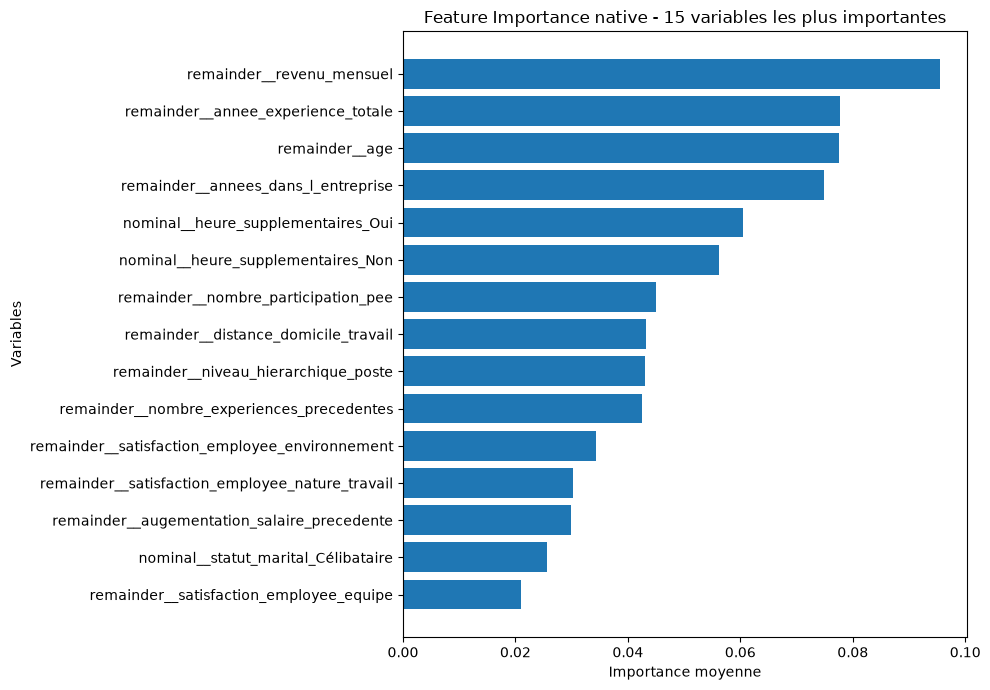

In [39]:
# Sélection des 15 variables les plus importantes

top_features_native = importance_native_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_native["Feature"],
    top_features_native["Importance"]
)

plt.xlabel("Importance moyenne")
plt.ylabel("Variables")
plt.title("Feature Importance native - 15 variables les plus importantes")

plt.tight_layout()
plt.show()

#### **Comparaison des méthodes**

In [40]:
# Comparaison des deux méthodes de Feature Importance

comparaison_importance = importance_df[["Feature", "Importance"]].rename(
    columns={"Importance": "Permutation"}
).merge(
    importance_native_df[["Feature", "Importance"]].rename(
        columns={"Importance": "Native"}
    ),
    on="Feature",
    how="outer"
)

# Classement selon chaque méthode
comparaison_importance["Rang_Permutation"] = (
    comparaison_importance["Permutation"]
    .rank(ascending=False, method="min")
)

comparaison_importance["Rang_Native"] = (
    comparaison_importance["Native"]
    .rank(ascending=False, method="min")
)

# Écart entre les deux classements
comparaison_importance["Ecart_Rang"] = (
    comparaison_importance["Rang_Permutation"]
    - comparaison_importance["Rang_Native"]
).abs()

comparaison_importance = comparaison_importance.sort_values(
    by="Rang_Permutation"
)

display(comparaison_importance.head(15))

,Feature,Permutation,Native,Rang_Permutation,Rang_Native,Ecart_Rang
14,nominal__heure_supplementaires_Oui,0.089458,0.060520,1.0,5.0,4.0
13,nominal__heure_supplementaires_Non,0.071150,0.056155,2.0,6.0,4.0
41,remainder__satisfaction_employee_environnement,0.056602,0.034392,3.0,11.0,8.0
36,remainder__nombre_experiences_precedentes,0.027515,0.042567,4.0,10.0,6.0
39,remainder__note_evaluation_precedente,0.022629,0.017602,5.0,19.0,14.0
44,remainder__satisfaction_employee_nature_travail,0.020412,0.030242,6.0,12.0,6.0
0,nominal__departement_Commercial,0.020385,0.017651,7.0,18.0,11.0
29,remainder__annees_dans_l_entreprise,0.020108,0.074918,8.0,4.0,4.0
43,remainder__satisfaction_employee_equipe,0.019219,0.020903,9.0,15.0,6.0
1,nominal__departement_Consulting,0.014979,0.013616,10.0,23.0,13.0



> - Les deux méthodes identifient les variables les plus importantes pour le modèl, "nominal__heure_supplementaires" et "	remainder__satisfaction_employee_environnement".
> - La **Permutation Importance** mesure l'impact d'une variable sur les performances du modèle.
> - La **Feature Importance native** mesure son importance dans les divisions du Random Forest.

#### **SHAP Beeswarm**

In [43]:
# Calcul des valeurs SHAP

explainer = shap.TreeExplainer(rf_optimise)
shap_values = explainer.shap_values(X_test)

print("Valeurs SHAP calculées")

Valeurs SHAP calculées


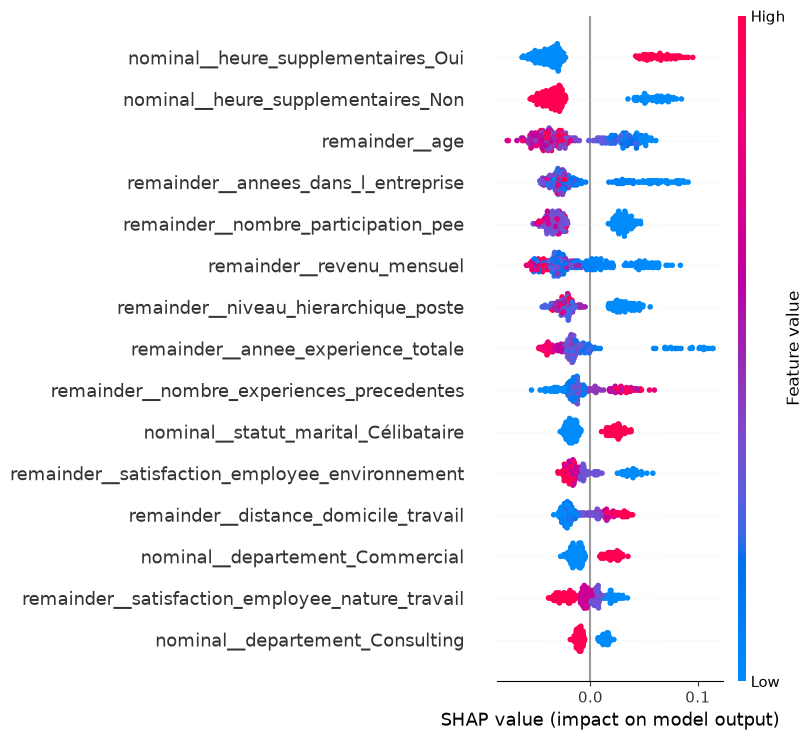

In [48]:
# SHAP Beeswarm - Classe Oui

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X_test.columns,
    max_display=15
)

#### **Convergences**

In [49]:
# Convergence des variables importantes entre les méthodes

# Importance SHAP moyenne
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_SHAP": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Importance_SHAP",
    ascending=False
)

# Top 15 de chaque méthode
top_shap = set(shap_importance.head(15)["Feature"])
top_permutation = set(importance_df.head(15)["Feature"])
top_native = set(importance_native_df.head(15)["Feature"])

# Variables communes aux trois méthodes
convergences = sorted(
    top_shap & top_permutation & top_native
)

print("Variables communes aux trois méthodes :")
for feature in convergences:
    print("-", feature)

print(f"\nNombre de variables communes : {len(convergences)}")

Variables communes aux trois méthodes :
- nominal__heure_supplementaires_Non
- nominal__heure_supplementaires_Oui
- remainder__annees_dans_l_entreprise
- remainder__distance_domicile_travail
- remainder__niveau_hierarchique_poste
- remainder__nombre_experiences_precedentes
- remainder__nombre_participation_pee
- remainder__satisfaction_employee_environnement
- remainder__satisfaction_employee_nature_travail

Nombre de variables communes : 9


> - **9 variables** sont identifiées comme importantes par les trois méthodes : SHAP, Permutation Importance et Feature Importance native.
> - Les variables communes concernent notamment les **heures supplémentaires**, l’**ancienneté**, la **distance domicile-travail**, le **niveau hiérarchique** et la **satisfaction au travail**.
> - Cette convergence renforce la **robustesse de l’interprétation** des variables importantes du modèle.

#### **Divergences**

In [50]:
# Identification des divergences entre les trois méthodes

top_permutation = set(importance_df.head(15)["Feature"])
top_native = set(importance_native_df.head(15)["Feature"])

# Importance SHAP moyenne absolue
shap_importance = np.abs(shap_values[:, :, 1]).mean(axis=0)

importance_shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": shap_importance
}).sort_values(
    by="Importance",
    ascending=False
)

top_shap = set(importance_shap_df.head(15)["Feature"])

# Variables présentes dans au moins une méthode
variables_union = top_permutation | top_native | top_shap

# Variables communes aux trois méthodes
variables_communes = top_permutation & top_native & top_shap

# Variables divergentes
variables_divergentes = variables_union - variables_communes

print("Variables divergentes :")
for variable in sorted(variables_divergentes):
    print("-", variable)

print("\nNombre de variables divergentes :", len(variables_divergentes))

Variables divergentes :
- nominal__departement_Commercial
- nominal__departement_Consulting
- nominal__poste_Cadre Commercial
- nominal__statut_marital_Célibataire
- remainder__age
- remainder__annee_experience_totale
- remainder__augementation_salaire_precedente
- remainder__nb_formations_suivies
- remainder__note_evaluation_precedente
- remainder__revenu_mensuel
- remainder__satisfaction_employee_equipe

Nombre de variables divergentes : 11


### **Comprendre les Shapley values**

#### **SHAP Scatter + color**

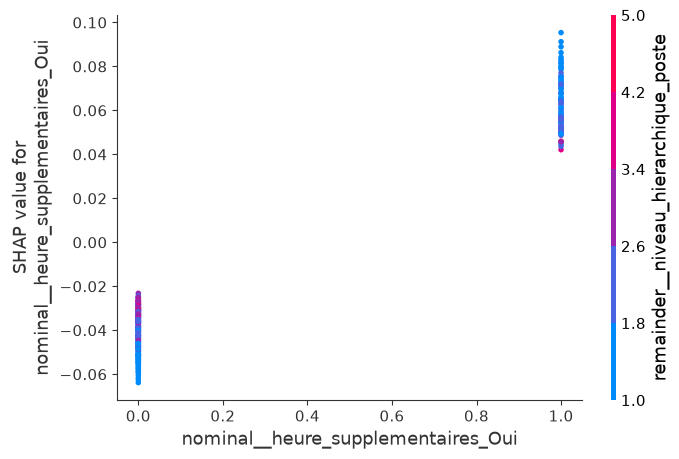

In [51]:
# SHAP Scatter + color

feature = "nominal__heure_supplementaires_Oui"

shap.dependence_plot(
    feature,
    shap_values[:, :, 1],
    X_test,
    interaction_index="auto",
    show=True
)

> - Les heures supplémentaires ont un **impact important** sur la prédiction d’attrition.
> - La présence d’heures supplémentaires (`Oui`) augmente fortement la contribution SHAP vers la classe **Oui**, tandis que leur absence (`Non`) contribue dans le sens opposé.
> - Le niveau hiérarchique influence également l’impact de cette variable, mais les heures supplémentaires restent le facteur dominant observé sur ce graphique.

### **Feature importance locale**

#### **Classe Oui → Waterfall**

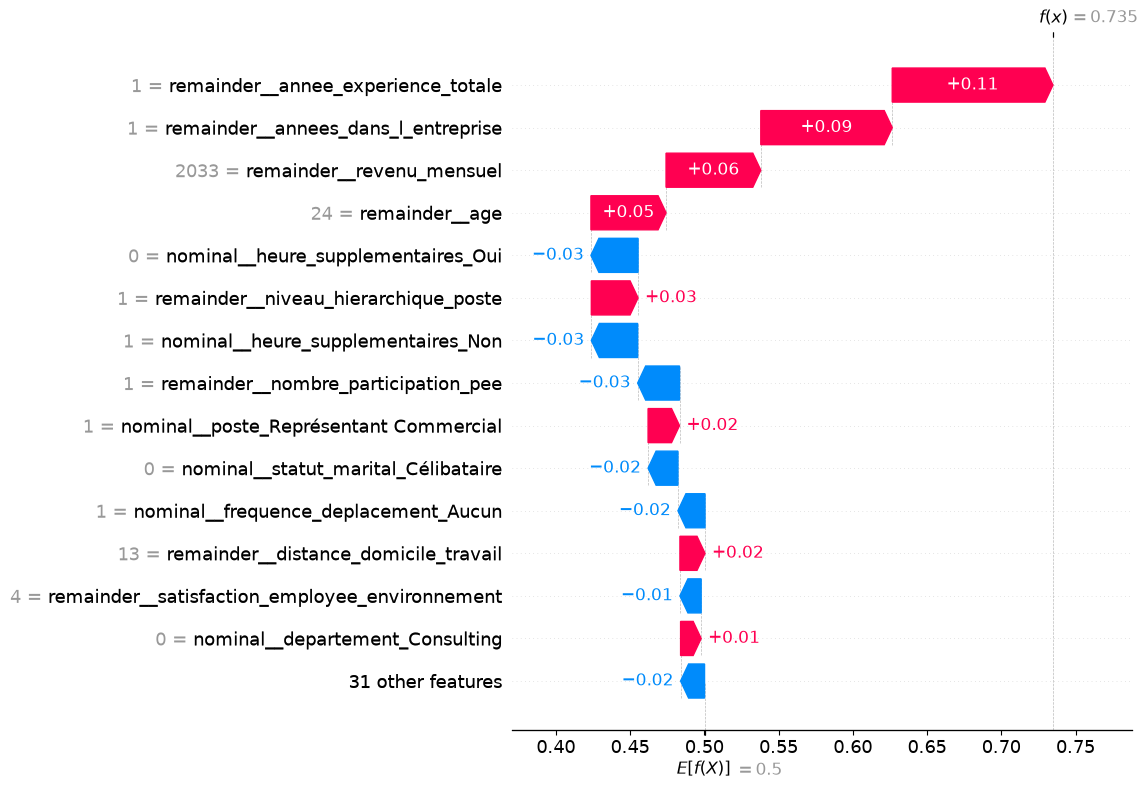

In [52]:
# Waterfall - Classe Oui

i = 0  # salarié sélectionné

exp_oui = shap.Explanation(
    values=shap_values[i, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp_oui, max_display=15)

> - La prédiction finale est de **0,735**, contre une valeur de base de **0,50**.
> - L'**expérience totale**, l'**ancienneté dans l'entreprise**, le **revenu mensuel** et l'**âge** contribuent principalement à augmenter la prédiction d'attrition.
> - Les variables en bleu diminuent la prédiction, tandis que les variables en rouge l'augmentent.

#### **Classe Non → Waterfall**

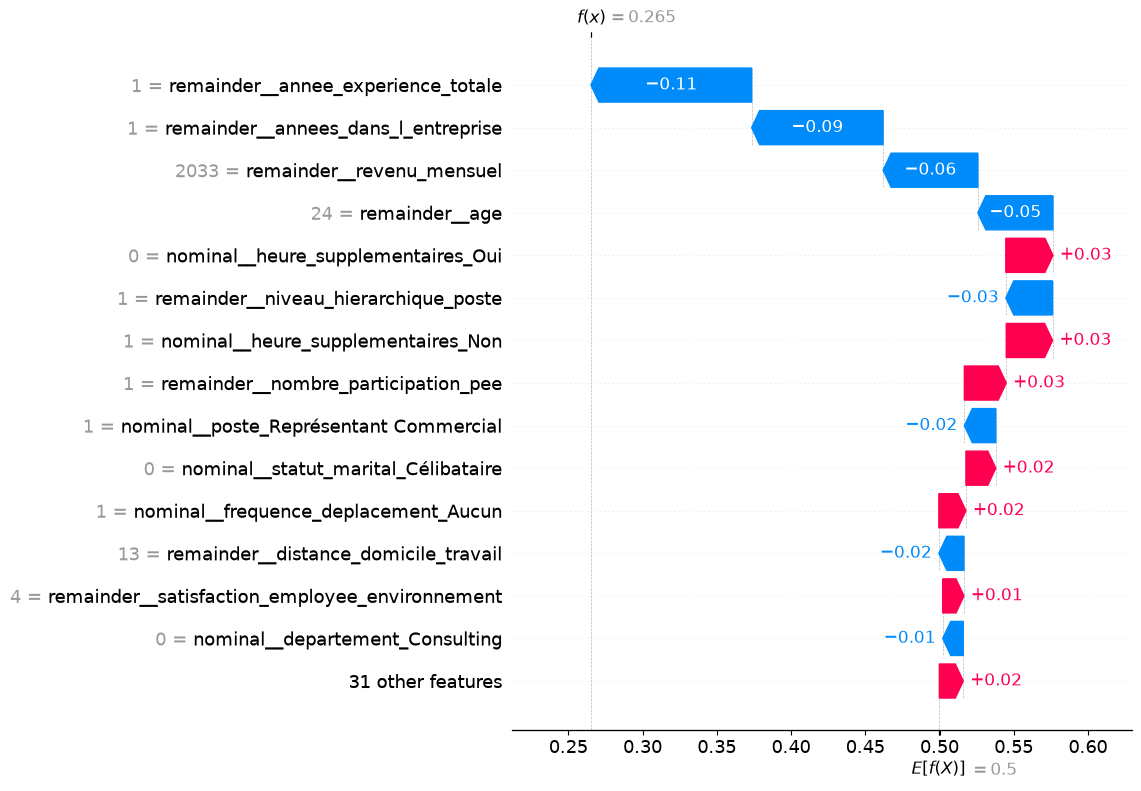

In [53]:
# Waterfall - Classe Non

i = 0  # salarié sélectionné

exp_non = shap.Explanation(
    values=shap_values[i, :, 0],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[i],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp_non, max_display=15)

> - La prédiction finale pour la classe **Non** est de **0,265**, contre une valeur de base de **0,50**.
> - L'**expérience totale**, l'**ancienneté dans l'entreprise**, le **revenu mensuel** et l'**âge** contribuent principalement à diminuer la prédiction.
> - Les variables en bleu diminuent la prédiction de la classe **Non**, tandis que les variables en rouge l'augmentent.

### **Conclusion d'Objectifs Data**

> - **E5 - Optimiser et interpréter le modèle :** optimiser les hyperparamètres du modèle retenu, évaluer ses performances et identifier les variables ayant le plus d'influence sur l'attrition à l'aide de SHAP.
> - Le modèle optimisé atteint un **F1-score de 0,531** et un **ROC-AUC de 0,799** sur le jeu de test.
> - Les analyses **Permutation Importance, Feature Importance native et SHAP** permettent d'identifier les principales variables associées à l'attrition.
> - Les résultats fournissent une base interprétable pour **comprendre et analyser les facteurs liés au départ des salariés**.

#### **Facteurs principaux associés à l'attrition**

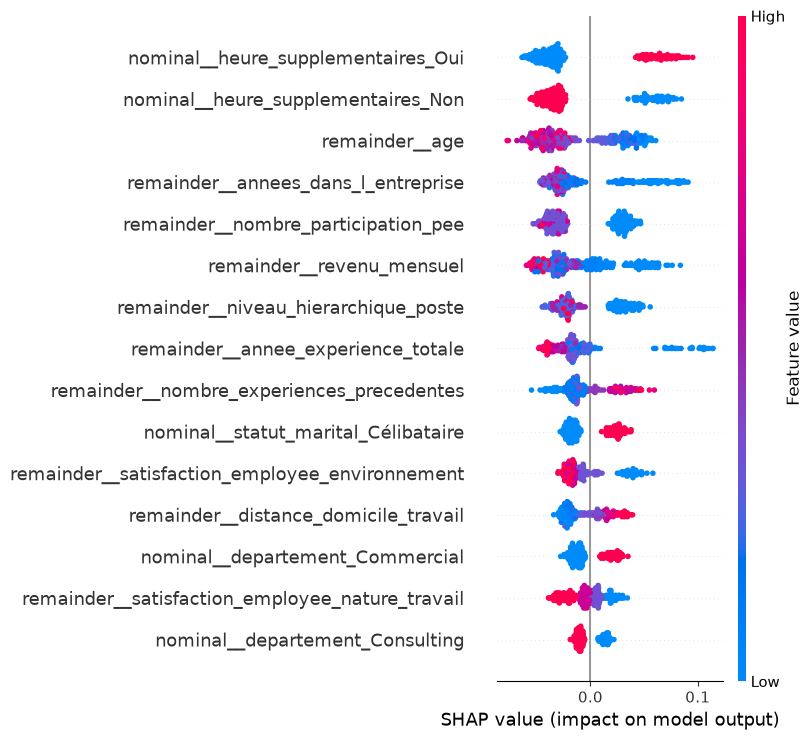

In [65]:
# SHAP Beeswarm - Facteurs principaux associés à l'attrition

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X_test.columns,
    max_display=15
)

> - Les variables les plus influentes dans les prédictions sont notamment **les heures supplémentaires**, **l’âge**, **l’ancienneté dans l’entreprise**, **le revenu mensuel** et **l’expérience professionnelle**.
> - Les valeurs SHAP positives augmentent la prédiction d’attrition, tandis que les valeurs négatives la diminuent. Le graphique montre ainsi que l’influence des variables varie selon le profil de chaque salarié.
> - Ces résultats permettent d’**identifier les principaux facteurs associés à l’attrition** et répondent ainsi à l’objectif d’améliorer la compréhension des profils présentant un risque de départ plus élevé.

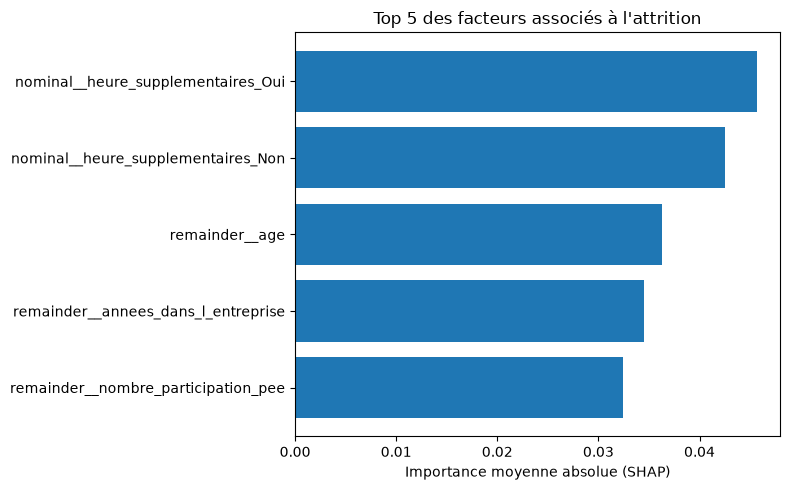

In [68]:
# Top 5 facteurs les plus importants selon SHAP

shap_values_oui = shap_values[:, :, 1]

importance_shap = np.abs(shap_values_oui).mean(axis=0)

top5_idx = np.argsort(importance_shap)[-5:][::-1]

plt.figure(figsize=(8, 5))

plt.barh(
    X_test.columns[top5_idx][::-1],
    importance_shap[top5_idx][::-1]
)

plt.xlabel("Importance moyenne absolue (SHAP)")
plt.title("Top 5 des facteurs associés à l'attrition")
plt.tight_layout()
plt.show()

### **Sauvegarde du jeu des données**

In [54]:
# Sauvegarde du jeu de données final

df_modelisation.to_csv(
    "df_modelisation_final.csv",
    index=False
)

print("Jeu de données sauvegardé")

Jeu de données sauvegardé
